In [1]:
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import transforms
from torchvision.datasets import MNIST
from torchvision.utils import make_grid
from tqdm import tqdm
import matplotlib.pyplot as plt
from d3pm_runner import DummyX0Model, D3PM
import bisect

## d3pm loss

In [2]:
n_samples = 2
cond = torch.tensor(5).cuda()
init_noise = torch.zeros((n_samples, 1, 32, 32)).cuda()

In [3]:
def cond_entropy(logits):
    # another way
    # from torch.distributions import Categorical
    # dist = Categorical(logits=logits)
    # pixel_entropy = dist.entropy()
    # h_x_y = pixel_entropy.sum(dim=(1, 2, 3)).mean()
    
    # logits: [B, 1, 32, 32, 2]
    probs = F.softmax(logits, dim=-1)
    log_probs = F.log_softmax(logits, dim=-1)
    pixel_entropy = -(probs * log_probs).sum(dim=-1)
    h_x_y = pixel_entropy.sum(dim=(1, 2, 3)).mean()
    return h_x_y

In [4]:
def d3pm_loss(model, x, t, cond):
    logits = model.model_predict(x, t, cond) # (batch, 1, 32, 32, 2)
    return cond_entropy(logits)

## mask loss

In [44]:
def mask_loss(output_mask, target_density=0.2, binarization_weight=0.01):
    """
    output_mask: Tensor [B, 1, 32, 32] (after sigmoid)
    target_density: Float (0.2 for 20%, 0.5 for 50%)
    """
    # 1. Sparsity Constraint: Mean of pixels should equal target_density
    current_density = output_mask.mean(dim=(1,2,3))
    sparsity_loss = F.mse_loss(current_density, target_density.to(output_mask.device))
    return sparsity_loss
    # # 2. Binarization Penalty: Encourages values to be 0 or 1, not 0.5 

# model

In [45]:
class MaskGenerator(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        # Embed 10 categories into a continuous space
        self.embedding = nn.Embedding(10, hidden_dim)
        self.semb = nn.Linear(32, hidden_dim)
        
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2048), # 2 * 32 * 32 = 1024
            # nn.Sigmoid()  # use gumbel
        )

    def forward(self, x, sparse):
        # x is a LongTensor of shape (batch_size,)
        sparse = sparse.float().reshape(-1,1)
        sparse_features = [torch.sin(sparse * 3.1415 * 2**i) for i in range(16)] + [
            torch.cos(sparse * 3.1415 * 2**i) for i in range(16)
        ]
        sx = torch.cat(sparse_features, dim=1).to(x.device)
        semb = self.semb(sx)
        
        embeds = self.embedding(x)
        mask = self.mlp(embeds + semb)
        return mask.view(-1, 1, 32, 32, 2)

def gumbel_mask(logits, temperature=0.5, hard=True):
    # logits shape: [B, 32, 32, 2]
    # 'hard=True' uses STE internally to return 0/1 but backprop through soft
    mask_2channel = F.gumbel_softmax(logits, tau=temperature, hard=hard)
    
    # Return only the channel representing '1'
    return mask_2channel[..., 1]

## train

In [61]:
model = MaskGenerator().cuda()
optim = torch.optim.Adam(model.parameters(), lr=3e-4)

In [62]:
N=2
n_T = 1000
d3pm = D3PM(DummyX0Model(1, N), n_T, num_classes=N, hybrid_loss_coeff=0.0, forward_type='absorb').cuda()
d3pm.load_state_dict(torch.load("models/model_absorb_cosine_209.pth"))
d3pm.eval()

D3PM(
  (x0_model): DummyX0Model(
    (down1): Sequential(
      (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (1): GroupNorm(2, 16, eps=1e-05, affine=True)
      (2): LeakyReLU(negative_slope=0.01)
      (3): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (4): GroupNorm(2, 16, eps=1e-05, affine=True)
      (5): LeakyReLU(negative_slope=0.01)
      (6): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (7): GroupNorm(2, 16, eps=1e-05, affine=True)
      (8): LeakyReLU(negative_slope=0.01)
    )
    (down2): Sequential(
      (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (1): GroupNorm(4, 32, eps=1e-05, affine=True)
      (2): LeakyReLU(negative_slope=0.01)
      (3): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (4): GroupNorm(4, 32, eps=1e-05, affine=True)
      (5): LeakyReLU(negative_slope=0.01)
      (6): Conv2d(32, 32, kernel_size=(5, 5), stride=(1,

In [63]:
cumprods = []
val = 1
for beta in d3pm.beta_t:
    # print(beta)
    val *= (1-beta)
    # print(val)
    cumprods.append(val.item())
cumprods = torch.tensor(cumprods[::-1])
# plt.plot(d3pm.beta_t)
# plt.show()
# plt.plot(cumprods)
# plt.show()

In [64]:
dataset = MNIST(
    "./data",
    train=True,
    download=True,
    transform=transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Pad(2),
        ]
    ),
)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True, num_workers=32)

/home/anvuong/miniconda3/envs/torch2/lib/python3.10/site-packages/torch/utils/data/dataloader.py:560: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 24, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [65]:
# check which t corresponds to the desired sparsity
# for 0.5 -> t=660
# for 0.15 -> t=900

x, cond = next(iter(dataloader))
x = (x * (N - 1)).round().long().clamp(0, N - 1)

count = x.sum(dim=(1,2,3))

xt = d3pm.q_sample(x.cuda(), 930*torch.ones(512).int().cuda(), torch.rand((*x.shape, 2)).cuda())
xt = xt.detach().cpu()
xtcount = xt.sum(dim=(1,2,3)) 

(xtcount/count).mean()

tensor(0.1064)

In [ ]:
n_epoch = 200
device = "cuda"

for i in range(n_epoch):

    pbar = tqdm(dataloader)
    loss_ema = None
    for x, cond in pbar:
        sparsity = torch.rand((x.shape[0], ))
        st = n_T-torch.searchsorted(cumprods, sparsity)
        
        optim.zero_grad()
        x = x.to(device)
        cond = cond.to(device)

        # discritize x to N bins
        x = (x * (N - 1)).round().long().clamp(0, N - 1)

        mask_logits = model(cond, sparsity)
        mask = gumbel_mask(mask_logits, temperature=0.5, hard=True)
        
        y = x*mask

        # calculate H(X|Y) loss
        hxy_loss = d3pm_loss(d3pm, y, st.cuda(), cond)
        sparsity_loss = 100*mask_loss(mask, sparsity)
        
        loss = hxy_loss + sparsity_loss

        loss.backward()

        if loss_ema is None:
            loss_ema = loss.item()
        else:
            loss_ema = 0.99 * loss_ema + 0.01 * loss.item()
        pbar.set_description(
            f"loss: {loss_ema:.4f},  H(X|Y): {hxy_loss.item():.4f}, sparsity_loss: {sparsity_loss.item():.4f}"
        )
        optim.step()


loss: 63.8022,  H(X|Y): 56.5675, sparsity_loss: 1.1141: 100%|██████████████| 118/118 [00:23<00:00,  5.05it/s]
loss: 55.6064,  H(X|Y): 52.9847, sparsity_loss: 0.7686: 100%|██████████████| 118/118 [00:23<00:00,  5.07it/s]
loss: 53.6302,  H(X|Y): 52.3684, sparsity_loss: 0.6642: 100%|██████████████| 118/118 [00:23<00:00,  5.04it/s]
loss: 52.4451,  H(X|Y): 52.5948, sparsity_loss: 0.6330:  25%|███▊           | 30/118 [00:08<00:14,  5.90it/s]

In [48]:
# torch.save(model.state_dict(), 'mask_gen.pth')

In [71]:
model = MaskGenerator().cuda()
model.load_state_dict(torch.load('mask_gen.pth'))

model.eval()

MaskGenerator(
  (embedding): Embedding(10, 128)
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2048, bias=True)
  )
)

In [52]:
x, cond = next(iter(dataloader))

In [59]:
mask = model(cond.cuda(), torch.tensor(0.15))
hard_mask = gumbel_mask(mask).cpu().detach()
y = hard_mask * x

123


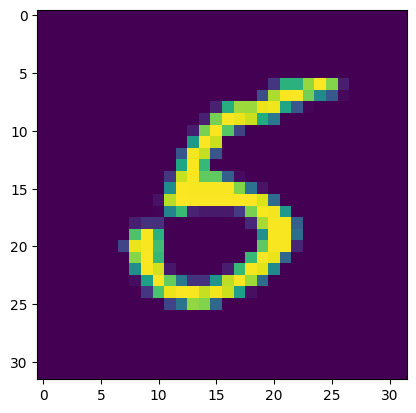

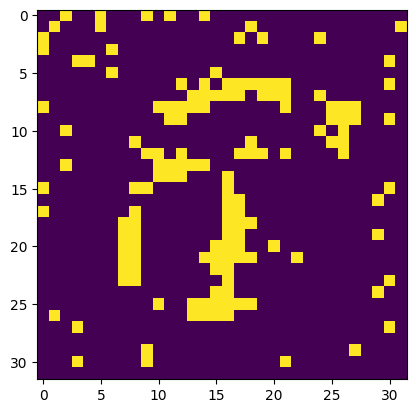

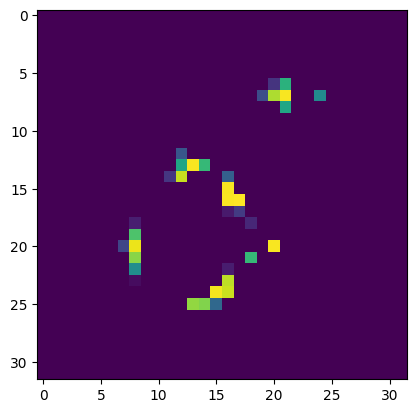

In [60]:
# idx = np.random.randint(256)
print(idx)

plt.imshow(x[idx][0])
plt.show()
plt.imshow(hard_mask[idx][0])
plt.show()
plt.imshow(y[idx][0])
plt.show()

In [46]:
hard_mask.shape

torch.Size([1, 1, 32, 32])

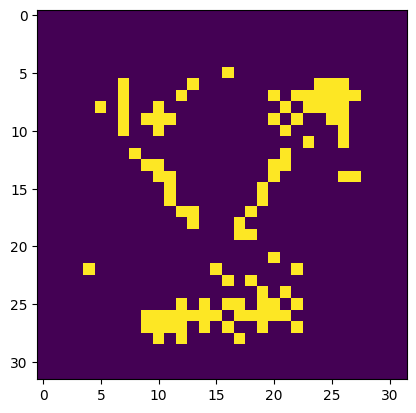

In [47]:
plt.imshow(hard_mask[0][0].detach().cpu().numpy())

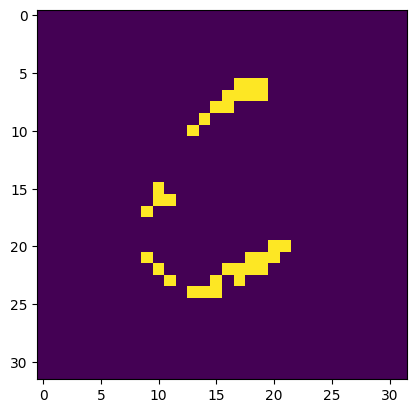

In [19]:
plt.imshow(y[0][0].detach().cpu().numpy())

In [31]:
torch.sum(hard_mask.detach().cpu())/32/32

tensor(0.2373)